<a href="https://colab.research.google.com/github/vinodr-intern/prodigyinfotechinternship/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [13]:
DATASET_PATH  = "/content/drive/MyDrive/dataset3"

In [14]:
def load_data(base_path):
    features = []
    labels = []

    categories = ["Cat", "Dog"]

    for label, category in enumerate(categories):
        path = os.path.join(base_path, category)

        for file in os.listdir(path):
            try:
                img_path = os.path.join(path, file)

                img = cv2.imread(img_path)
                img = cv2.resize(img, (64, 64))
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                hog_features = hog(
                    gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    transform_sqrt=True
                )

                features.append(hog_features)
                labels.append(label)

            except:
                continue

    return np.array(features), np.array(labels)

In [15]:
import os
import cv2
import numpy as np
from skimage.feature import hog

In [16]:
import os
import cv2
import numpy as np
import joblib

from tqdm import tqdm
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [17]:
import os


In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [21]:
DATASET_PATH = "/content/drive/MyDrive/dataset3"

In [22]:
print(os.listdir(DATASET_PATH))

['readme[1].txt', 'CDLA-Permissive-2.0.pdf', 'kagglecatsanddogs_5340.zip', 'PetImages']


In [26]:
DATASET_PATH = "/content/drive/MyDrive/dataset3"

!unzip "/content/drive/MyDrive/dataset3/kagglecatsanddogs_5340.zip" -d "/content/drive/MyDrive/dataset3"

Archive:  /content/drive/MyDrive/dataset3/kagglecatsanddogs_5340.zip
replace /content/drive/MyDrive/dataset3/PetImages/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [24]:
import os
print(os.listdir(DATASET_PATH))

['readme[1].txt', 'CDLA-Permissive-2.0.pdf', 'kagglecatsanddogs_5340.zip', 'PetImages']


In [25]:
print(os.listdir(DATASET_PATH + "/PetImages"))

['Dog', 'Cat']


In [28]:
DATASET_PATH = "/content/drive/MyDrive/dataset3/PetImages"

In [29]:
def load_data(base_path):
    features = []
    labels = []

    categories = ["Cat", "Dog"]   # IMPORTANT

    for label, category in enumerate(categories):
        path = os.path.join(base_path, category)

        print(f"Loading {category}...")

        for file in os.listdir(path):
            try:
                img_path = os.path.join(path, file)

                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.resize(img, (64, 64))
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                hog_features = hog(
                    gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    transform_sqrt=True
                )

                features.append(hog_features)
                labels.append(label)

            except:
                continue

    return np.array(features), np.array(labels)

In [30]:

print("Loading dataset...")
X, y = load_data(DATASET_PATH)

print("Shape:", X.shape)

Loading dataset...
Loading Cat...
Loading Dog...
Shape: (24997, 1764)


In [31]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = SVC(kernel='rbf', C=10)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7796
              precision    recall  f1-score   support

           0       0.79      0.77      0.78      2515
           1       0.77      0.79      0.78      2485

    accuracy                           0.78      5000
   macro avg       0.78      0.78      0.78      5000
weighted avg       0.78      0.78      0.78      5000



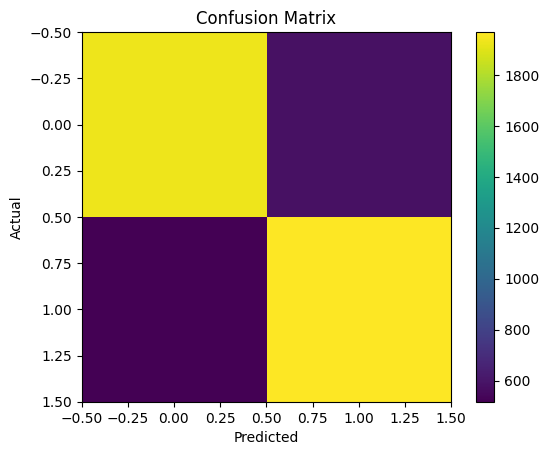

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
import joblib

joblib.dump(model, "cat_dog_svm.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [34]:
def predict_image(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return "Image not found"

    img = cv2.resize(img, (64, 64))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        transform_sqrt=True
    )

    features = features.reshape(1, -1)
    features = scaler.transform(features)

    pred = model.predict(features)

    return "Dog 🐶" if pred[0] == 1 else "Cat 🐱"

In [35]:
print(predict_image("/content/drive/MyDrive/dataset3/PetImages/Cat/0.jpg"))
print(predict_image("/content/drive/MyDrive/dataset3/PetImages/Dog/0.jpg"))

Cat 🐱
Dog 🐶


In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=200)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# retrain
model = SVC(kernel='rbf', C=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, y_pred))

Improved Accuracy: 0.7812
